# Online Retail Customer Segmentation

### Premium End-to-End Workflow

This notebook builds a professional RFM-based customer segmentation pipeline, from raw transaction ingestion to business-ready segment deployment.

In [1]:
import pandas as pd
import sqlite3

## Phase 1: Data Ingestion & SQL Foundation

### Step 1: Initialize Database Session

Set up the SQLite connection that will store cleaned retail transactions for downstream analytics.

### Step 2: Load Source Dataset

Read the raw Online Retail CSV into a DataFrame, preserving character integrity for global transaction records.

In [2]:
# 1. Connect to a new database for our real data
conn = sqlite3.connect('retail_real.db')
print("Loading CSV into Pandas DataFrame...")

Loading CSV into Pandas DataFrame...


### Step 3: Data Quality Screening

Remove records with missing customer identifiers to ensure valid customer-level analytics.

In [3]:
# 2. Load the raw dataset 
# (Encoding is often needed for European datasets with special characters)
df = pd.read_csv('online_retail.csv', encoding='unicode_escape')
print(f"Initial row count: {len(df)}")

Initial row count: 1067371


### Step 4: Persist Clean Data to SQL

Write the curated transaction dataset to a durable SQL table for reproducible analytics.

In [4]:
# 3. Essential Data Science Cleaning
# For RFM analysis, we MUST know who the customer is. 
# Real datasets often have missing (null) IDs for guest checkouts. We drop them.
df = df.dropna(subset=['Customer ID'])
print(f"Cleaned row count: {len(df)}")

Cleaned row count: 824364


### Step 5: Validate Ingestion Integrity

Run a SQL sanity check to confirm successful write and table accessibility.

In [5]:
# 4. Pipe the DataFrame directly into SQL
print("Writing to SQL database...")
df.to_sql(
    name='transactions', # The table name we are creating
    con=conn,            # The database connection
    if_exists='replace', # If the table exists, overwrite it
    index=False          # Don't create a SQL column for the Pandas row numbers
)

print("Success! Data ingested.")

Writing to SQL database...
Success! Data ingested.


In [6]:
# 5. Verify by querying SQL directly
test_query = pd.read_sql("SELECT * FROM transactions LIMIT 5", conn)
print("\nFirst 5 rows from the SQL database:")
print(test_query)

conn.close()


First 5 rows from the SQL database:
  Invoice StockCode                          Description  Quantity  \
0  489434     85048  15CM CHRISTMAS GLASS BALL 20 LIGHTS        12   
1  489434    79323P                   PINK CHERRY LIGHTS        12   
2  489434    79323W                  WHITE CHERRY LIGHTS        12   
3  489434     22041         RECORD FRAME 7" SINGLE SIZE         48   
4  489434     21232       STRAWBERRY CERAMIC TRINKET BOX        24   

           InvoiceDate  Price  Customer ID         Country  
0  2009-12-01 07:45:00   6.95      13085.0  United Kingdom  
1  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
2  2009-12-01 07:45:00   6.75      13085.0  United Kingdom  
3  2009-12-01 07:45:00   2.10      13085.0  United Kingdom  
4  2009-12-01 07:45:00   1.25      13085.0  United Kingdom  


## Phase 2: Feature Engineering (RFM)

### Step 6: Build Customer-Level RFM Features

Generate Recency, Frequency, and Monetary features using SQL for robust segmentation inputs.

In [7]:
# Connect to whichever database you built in Step 1
conn = sqlite3.connect('retail_real.db')

# The Advanced SQL Query (FIXED)
rfm_query = """
WITH reference AS (
    -- 1. Find the absolute latest date in the dataset
    SELECT MAX(InvoiceDate) AS max_date 
    FROM transactions
)
SELECT 
    t."Customer ID" AS customer_id,
    
    -- 2. RECENCY: Days since last purchase
    CAST(julianday(r.max_date) - julianday(MAX(t.InvoiceDate)) AS INTEGER) AS recency,
    
    -- 3. FREQUENCY: Count of invoices (transactions)
    COUNT(DISTINCT t.Invoice) AS frequency,
    
    -- 4. MONETARY: Total spending
    ROUND(SUM(t.Quantity * t.Price), 2) AS monetary

FROM transactions t
CROSS JOIN reference r

-- DATA CLEANING (VERY IMPORTANT)
WHERE t."Customer ID" IS NOT NULL
AND t.Quantity > 0
AND t.Price > 0

GROUP BY t."Customer ID"
"""

# Execute the query
rfm_df = pd.read_sql(rfm_query, conn)

print("Feature Engineering Complete. Here are the first few rows of the RFM DataFrame:")
print(rfm_df.head())

conn.close()

Feature Engineering Complete. Here are the first few rows of the RFM DataFrame:
   customer_id  recency  frequency  monetary
0      12346.0      325         12  77556.46
1      12347.0        1          8   5633.32
2      12348.0       74          5   2019.40
3      12349.0       18          4   4428.69
4      12350.0      309          1    334.40


## Phase 3: Clustering Model Development

### Step 7: Import ML Libraries

Load plotting and machine learning dependencies for scaling and K-Means modeling.

In [8]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

Matplotlib is building the font cache; this may take a moment.
Could not save font_manager cache Lock error: Matplotlib failed to acquire the following lock file:
    C:\Users\hp\.matplotlib\fontlist-v390.json.matplotlib-lock
This maybe due to another process holding this lock file.  If you are sure no
other Matplotlib process is running, remove this file and try again.


### Step 8: Prepare Clustering Features

Select the RFM variables that will define customer behavior profiles.

In [9]:
# Assume 'rfm_df' is the DataFrame we created in Step 2.
# 1. Isolate the features (we don't cluster on customer_id)
features = rfm_df[['recency', 'frequency', 'monetary']]

### Step 9: Standardize Feature Space

Scale inputs to ensure equal influence across recency, frequency, and monetary dimensions.

In [10]:
# # 2. Scale the Data (The crucial step)
# # This transforms our data so every column has a mean of 0 and a standard deviation of 1.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

### Step 10: Evaluate Optimal Cluster Count

Apply the elbow method to identify the most stable and interpretable number of customer clusters.

In [11]:
# 3. The Elbow Method (Finding optimal K)
# We test 1 through 10 clusters and record the WCSS (Variance).
wcss = []
for k in range(1, 11):
    # n_init=10 means it will randomly drop centroids 10 times and keep the best run
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(scaled_features)
    wcss.append(kmeans_test.inertia_) # inertia_ is the Scikit-Learn term for WCSS

In [12]:
wcss

[17634.00000000002,
 12114.97617198955,
 7124.4068145158835,
 5166.45148163619,
 3910.332099400388,
 3304.4440091260535,
 2737.0460042006466,
 2253.96465805868,
 1910.3102565233905,
 1648.8609378415722]

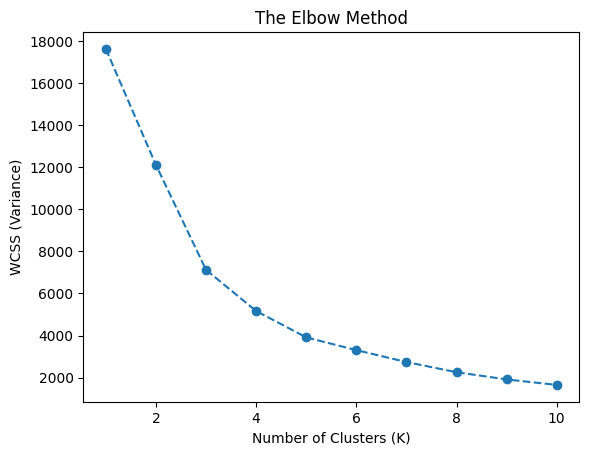

In [13]:
# (Optional) Plot the Elbow Graph to visually confirm the best 'K'
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('The Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS (Variance)')
plt.show()

### Step 11: Train Final K-Means Model

Fit the production clustering model using the selected value of K.

In [14]:
# 4. Train the Final Model
# Based on standard retail analysis, 3 to 4 clusters is usually the sweet spot.
# We will proceed with K=3 (e.g., VIPs, Regulars, Churning)
final_model = KMeans(n_clusters=3, random_state=42, n_init=10)
final_model.fit(scaled_features)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",3
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",10
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",42
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


### Step 12: Assign Cluster Labels

Attach model-generated clusters to each customer profile for downstream interpretation.

In [15]:
# 5. Assign the mathematical clusters back to our real business data
rfm_df['cluster'] = final_model.labels_
rfm_df['cluster']

0       1
1       1
2       1
3       1
4       0
       ..
5873    1
5874    0
5875    0
5876    0
5877    1
Name: cluster, Length: 5878, dtype: int32

### Step 13: Interpret Segment Profiles

Summarize each cluster’s behavioral signature to translate ML output into business insight.

In [16]:
# 6. Business Analysis: What do these clusters actually look like?
# We group by the new cluster label and find the average RFM values for each.
cluster_summary = rfm_df.groupby('cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': ['mean', 'count'] # Count tells us how many customers are in each group
}).round(1)

print("\n--- Final Customer Segments ---")
print(cluster_summary)


--- Final Customer Segments ---
        recency frequency  monetary      
           mean      mean      mean count
cluster                                  
0         460.5       2.2     763.1  2012
1          65.1       7.7    3324.2  3848
2          24.4     162.6  189805.1    18


In [17]:
import plotly.express as px

## Phase 4: Executive Visualization

### Step 14: Initialize Interactive Visualization Stack

Prepare Plotly for high-impact, presentation-ready 3D customer segmentation views.

In [18]:
# 1. The "Gotcha" Fix: Convert cluster numbers to strings
# K-Means outputs clusters as integers (0, 1, 2). 
# If we don't convert them to strings, Plotly will treat them as a continuous 
# math gradient (light blue to dark blue) instead of distinct, separate categories.
rfm_df['cluster'] = rfm_df['cluster'].astype(str)

print("Generating interactive 3D scatter plot...")

Generating interactive 3D scatter plot...


### Step 15: Build 3D Segment Plot

Construct an interactive RFM cluster view for exploratory and stakeholder analysis.

In [19]:
# 2. Build the Plotly Figure
fig = px.scatter_3d(
    rfm_df,
    x='recency',     # X-axis: Days since last purchase
    y='frequency',   # Y-axis: Number of purchases
    z='monetary',    # Z-axis: Total spend
    color='cluster', # Color-code the dots by their K-Means group
    hover_data=['customer_id'], # Show the actual customer ID when hovering
    title='Smart Customer Segmentation: 3D RFM Clusters',
    color_discrete_sequence=px.colors.qualitative.Set1, # Use bold, distinct colors
    opacity=0.7      # Slight transparency helps when dots overlap
)

### Step 16: Refine Presentation Layout

Apply clean axis labels and spacing to deliver a polished executive-ready visualization.

In [20]:
# 3. Clean up the layout for presentation
fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=40), # Removes unnecessary white space
    scene=dict(
        xaxis_title='Recency (Days)',
        yaxis_title='Frequency (Count)',
        zaxis_title='Monetary Spend ($)'
    )
)

## Phase 5: Segment Deployment & Business Activation

### Step 17: Open Deployment Connection

Reconnect to the production database context for segment publishing.

In [21]:
# Assume 'rfm_df' is still in memory from Step 4.
# 1. Connect to our existing database
conn = sqlite3.connect('retail_real.db')

### Step 18: Prepare Deployment Dataset

Extract only customer IDs and final segment labels for operational use.

In [22]:
# 2. Isolate the deployment data
# We don't need to push recency/frequency/monetary back, just the results.
deployment_df = rfm_df[['customer_id', 'cluster']].copy()

### Step 19: Map Clusters to Business Segments

Translate numeric clusters into intuitive labels for business and marketing teams.

In [23]:
# Updated mapping based on the actual cluster characteristics in your data
segment_mapping = {
    '2': 'VIPs',               # High frequency, High monetary, Low recency
    '1': 'Recent Regulars',    # Moderate across all metrics
    '0': 'At Risk / Churning'  # High recency (haven't visited in 400+ days)
}

deployment_df['segment_name'] = deployment_df['cluster'].astype(str).map(segment_mapping)

In [24]:
# We ensure 'cluster' is a string before mapping
deployment_df['segment_name'] = deployment_df['cluster'].astype(str).map(segment_mapping)

print("Deploying customer segments to the database...")

Deploying customer segments to the database...


### Step 20: Publish Segments to SQL

Deploy final customer segment labels to a dedicated table for cross-functional access.

In [25]:
# 3. Push to the SQL table
deployment_df.to_sql(
    name='customer_segments', # Keep this name consistent
    con=conn,
    if_exists='replace', 
    index=False
)

print("Deployment Successful! Data is now live in table: customer_segments")

Deployment Successful! Data is now live in table: customer_segments


### Step 21: Validate Real-World Marketing Query

Run a practical SQL join to demonstrate how teams can immediately activate segment intelligence.

In [26]:
# --- THE REAL-WORLD TEST ---
# 4. How Marketing uses this: A SQL JOIN

marketing_query = """
SELECT 
    s.customer_id,
    s.segment_name,
    t.Invoice,
    t.InvoiceDate,
    t.Quantity,
    t.Price
FROM customer_segments s
JOIN transactions t 
    ON s.customer_id = t."Customer ID"
WHERE s.segment_name = 'At Risk / Churning'
ORDER BY t."Customer ID", t.InvoiceDate DESC
LIMIT 5;
"""

marketing_pull = pd.read_sql(marketing_query, conn)

print("\n--- Marketing Department Query Result ---")
print(marketing_pull)

conn.close()


--- Marketing Department Query Result ---
   customer_id        segment_name Invoice          InvoiceDate  Quantity  \
0      12350.0  At Risk / Churning  543037  2011-02-02 16:01:00         1   
1      12350.0  At Risk / Churning  543037  2011-02-02 16:01:00         6   
2      12350.0  At Risk / Churning  543037  2011-02-02 16:01:00        10   
3      12350.0  At Risk / Churning  543037  2011-02-02 16:01:00        12   
4      12350.0  At Risk / Churning  543037  2011-02-02 16:01:00        12   

   Price  
0  40.00  
1   2.95  
2   0.85  
3   0.85  
4   1.25  
